In [4]:
import pandas as pd
import numpy as np

In [5]:
print(pd.__version__)
print(np.__version__)

3.0.2
2.4.4


In [6]:
df = pd.read_csv("https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [7]:
print(df.shape)
print(df.dtypes)
print(df.isnull().sum())

(891, 12)
PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [8]:
print(df['Survived'].value_counts())
print(df.groupby('Sex')['Survived'].mean())

Survived
0    549
1    342
Name: count, dtype: int64
Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64


In [12]:
import sys
print(sys.executable)

/Library/Frameworks/Python.framework/Versions/3.14/bin/python3.14


In [13]:
import sys
!{sys.executable} -m pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 72.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 85.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 97.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib] 6/7 [matplotlib]

[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip3 install --upgrade pip


Matplotlib is building the font cache; this may take a moment.


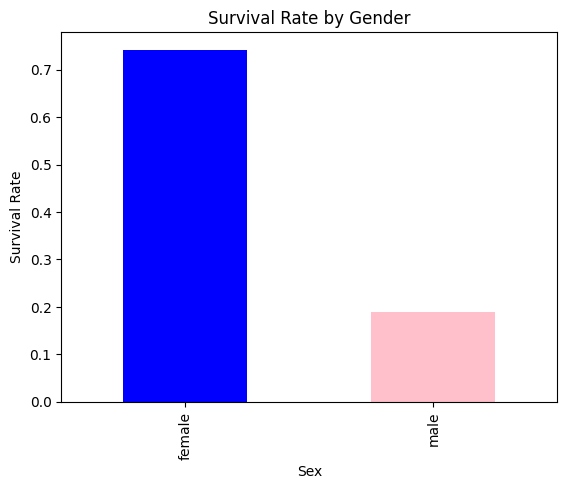

In [14]:
import matplotlib.pyplot as plt

df.groupby('Sex')['Survived'].mean().plot(kind='bar', color=['blue','pink'])
plt.title('Survival Rate by Gender')
plt.ylabel('Survival Rate')
plt.show()


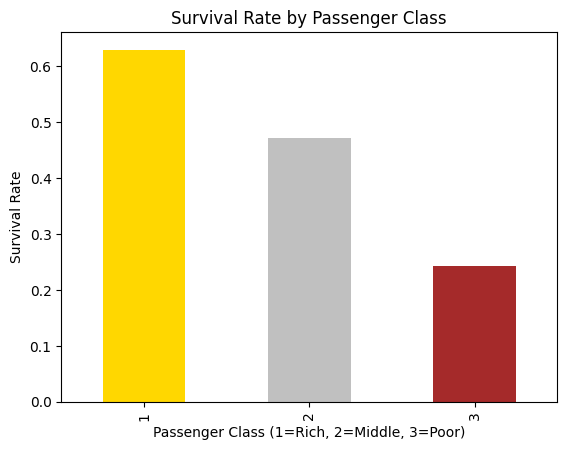

In [15]:
df.groupby('Pclass')['Survived'].mean().plot(kind='bar', color=['gold','silver','brown'])
plt.title('Survival Rate by Passenger Class')
plt.xlabel('Passenger Class (1=Rich, 2=Middle, 3=Poor)')
plt.ylabel('Survival Rate')
plt.show()

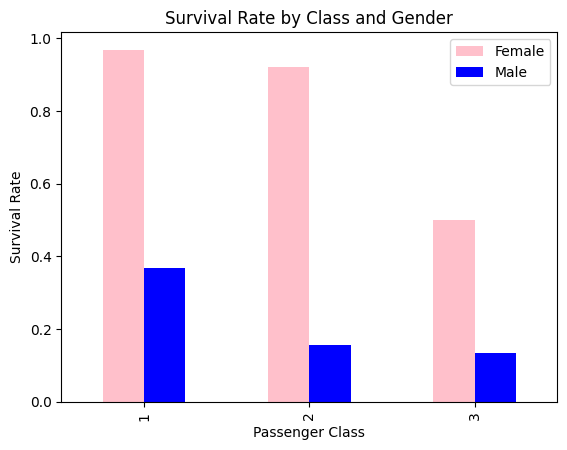

In [17]:
df.groupby(['Pclass','Sex'])['Survived'].mean().unstack().plot(kind='bar', color=['pink','blue'])
plt.title('Survival Rate by Class and Gender')
plt.xlabel('Passenger Class')
plt.ylabel('Survival Rate')
plt.legend(['Female','Male'])
plt.show()

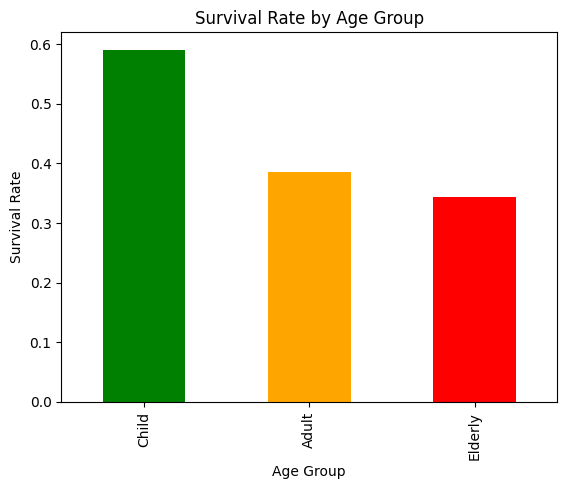

In [18]:
df['AgeGroup'] = pd.cut(df['Age'], 
                         bins=[0, 15, 50, 100], 
                         labels=['Child', 'Adult', 'Elderly'])

df.groupby('AgeGroup')['Survived'].mean().plot(kind='bar', color=['green','orange','red'])
plt.title('Survival Rate by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Survival Rate')
plt.show()

In [19]:
df.to_csv('titanic_analysis.csv', index=False)